<a href="https://colab.research.google.com/github/UH-GROUP-X/Hackathon26/blob/main/UH_GROUP_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RMDS Hackathon

# Setup file path and install packages

In [1]:
# To get the training dataset from the Github.

import pandas as pd
datapath1 = "https://raw.githubusercontent.com/UH-GROUP-X/Hackathon26/refs/heads/main/dataset_C_training.csv"
df1 = pd.read_csv(datapath1)
df1.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [2]:
# To get the testing dataset from the Github.

import pandas as pd
datapath2 = "https://raw.githubusercontent.com/UH-GROUP-X/Hackathon26/refs/heads/main/dataset_C_testing.csv"
df2 = pd.read_csv(datapath2)
df2.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,0,4,2,2.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,"MSA, Not Principle City",0.0,0.0,0,2,3,2.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,0,3,2,2.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Employed,Non-MSA,1.0,0.0,0,4,4,1.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,Non-MSA,0.0,0.0,0,3,2,1.0,wholesale


In [3]:
# To mount the google drive to later use it for saving the files.

from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted')

Mounted at /content/drive
Google Drive mounted


In [4]:
!pip install -q xgboost lightgbm shap imbalanced-learn

# 1. Configuration

In [5]:
# Configration for the submission files.

DRIVE_ROOT = '/content/drive/MyDrive/'
DATA_FOLDER = 'hackathon/'
SUBMISSION_DIR = DRIVE_ROOT + DATA_FOLDER + 'submissions/'

# To define the target and other variables.
TARGET_COL = 'covid_vaccine'
ID_COL = 'respondent_id'
TASK = 'classification'
RANDOM_STATE = 42

TRAIN_PATH = df1 # train path
TEST_PATH  = df2 # test path
SUBMISSION_DIR = DRIVE_ROOT + DATA_FOLDER + 'submissions/'
GROUP_NUMBER = 'X'

import os
os.makedirs(SUBMISSION_DIR, exist_ok=True)

print(f'Train      : {TRAIN_PATH}')
print(f'Test       : {TEST_PATH}')
print(f'Submissions: {SUBMISSION_DIR}')
print(f'Group      : {GROUP_NUMBER}')

Train      :       respondent_id  covid_concern  covid_knowledge  \
0                 1            3.0              1.0   
1                 2            2.0              1.0   
2                 3            0.0              2.0   
3                 4            2.0              2.0   
4                 5            1.0              1.0   
...             ...            ...              ...   
4751           4752            0.0              1.0   
4752           4753            2.0              1.0   
4753           4754            3.0              2.0   
4754           4755            1.0              2.0   
4755           4756            1.0              2.0   

      behavioral_antiviral_meds  behavioral_avoidance  behavioral_face_mask  \
0                           0.0                   1.0                   0.0   
1                           0.0                   1.0                   0.0   
2                           0.0                   0.0                   0.0   
3         

# 2. Imports

In [6]:
# To import all the important libraries.

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# libraries for the Pre-processing.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import ( StandardScaler, RobustScaler, LabelEncoder,
                                    OneHotEncoder, OrdinalEncoder)

# To import all the Models.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# For Evaluation.
from sklearn.model_selection import ( train_test_split, cross_val_score,
                                      StratifiedKFold, RandomizedSearchCV)
from sklearn.metrics import ( accuracy_score, f1_score, roc_auc_score,
                              precision_score, recall_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

# For XAI.
import shap

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
pd.set_option('display.max_columns', 40)

# 3. Load data

In [7]:
# To load the data.

train_raw = pd.read_csv(datapath1)
test_raw  = pd.read_csv(datapath2)

print(f'Train : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns')
print(f'Test  : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} columns')
train_raw.head()

Train : 4,756 rows × 31 columns
Test  : 4,749 rows × 30 columns


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,chronic_med_condition,child_under_6_months,health_worker,health_insurance,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,NaN,45 - 54 Years,12 Years,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,45 - 54 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,65+ Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


# 4. Exploratory Data Analysis (EDA)

In [8]:
# To get the overview.

train_raw.info()
print()
display(train_raw.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   respondent_id                 4756 non-null   int64  
 1   covid_concern                 4744 non-null   float64
 2   covid_knowledge               4729 non-null   float64
 3   behavioral_antiviral_meds     4742 non-null   float64
 4   behavioral_avoidance          4729 non-null   float64
 5   behavioral_face_mask          4754 non-null   float64
 6   behavioral_wash_hands         4747 non-null   float64
 7   behavioral_large_gatherings   4746 non-null   float64
 8   behavioral_outside_home       4742 non-null   float64
 9   behavioral_touch_face         4735 non-null   float64
 10  chronic_med_condition         4587 non-null   float64
 11  child_under_6_months          4621 non-null   float64
 12  health_worker                 4624 non-null   float64
 13  hea

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,NaN,NaN,NaN,2378.5,1373.08327,1.0,1189.75,2378.5,3567.25,4756.0
covid_concern,4744.0,NaN,NaN,NaN,1.648609,0.903204,0.0,1.0,2.0,2.0,3.0
covid_knowledge,4729.0,NaN,NaN,NaN,1.296469,0.615705,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4742.0,NaN,NaN,NaN,0.053353,0.22476,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4729.0,NaN,NaN,NaN,0.733347,0.442256,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4754.0,NaN,NaN,NaN,0.072991,0.260149,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4747.0,NaN,NaN,NaN,0.839267,0.367323,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4746.0,NaN,NaN,NaN,0.3563,0.478956,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4742.0,NaN,NaN,NaN,0.329186,0.469967,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4735.0,NaN,NaN,NaN,0.693981,0.460886,0.0,0.0,1.0,1.0,1.0


# **DOCTOR RECOMMENDATION:**

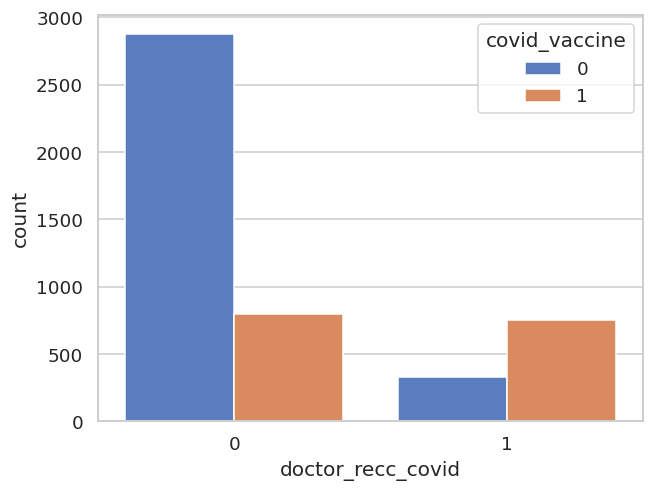

In [9]:
sns.countplot( x='doctor_recc_covid',
               hue='covid_vaccine',
               data=train_raw)
plt.show()

# **AGE GROUP:**

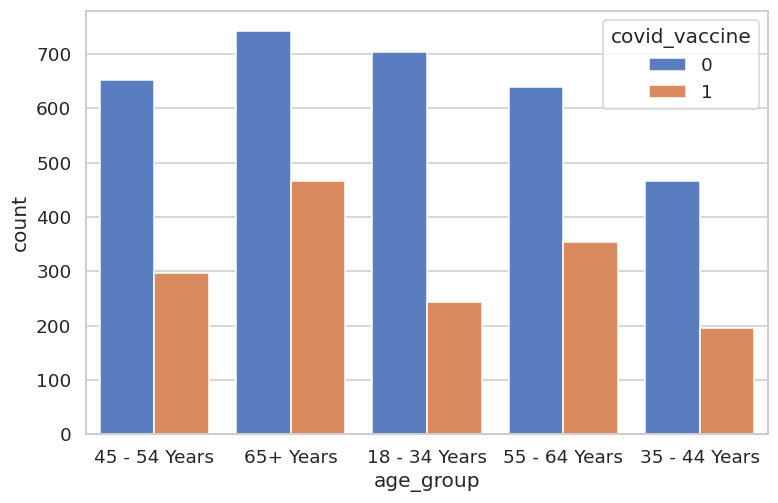

In [10]:
plt.figure(figsize=(8,5))

sns.countplot( x='age_group',
               hue='covid_vaccine',
               data=train_raw )

plt.show()

# **COVID EFFECTIVE:**

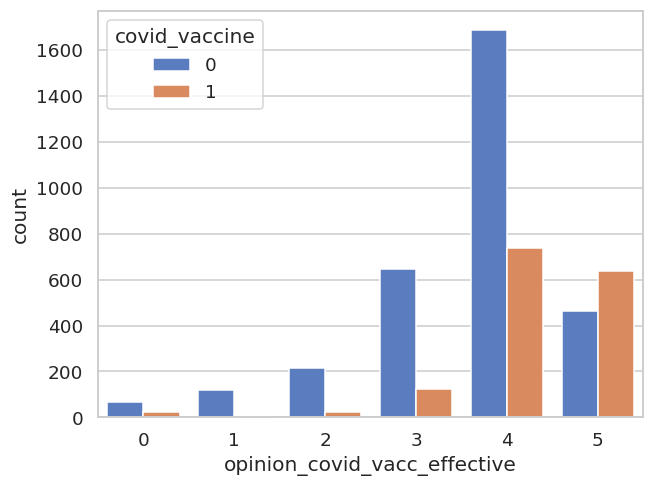

In [11]:
sns.countplot( x='opinion_covid_vacc_effective',
               hue='covid_vaccine',
               data=train_raw)
plt.show()

## 4.1. Missing values.

,Count,Pct (%)
employment_sector,2330,48.99
health_insurance,1908,40.12
income_poverty,748,15.73
rent_or_own,329,6.92
employment_status,238,5.00
marital_status,231,4.86
education,228,4.79
chronic_med_condition,169,3.55
child_under_6_months,135,2.84
health_worker,132,2.78


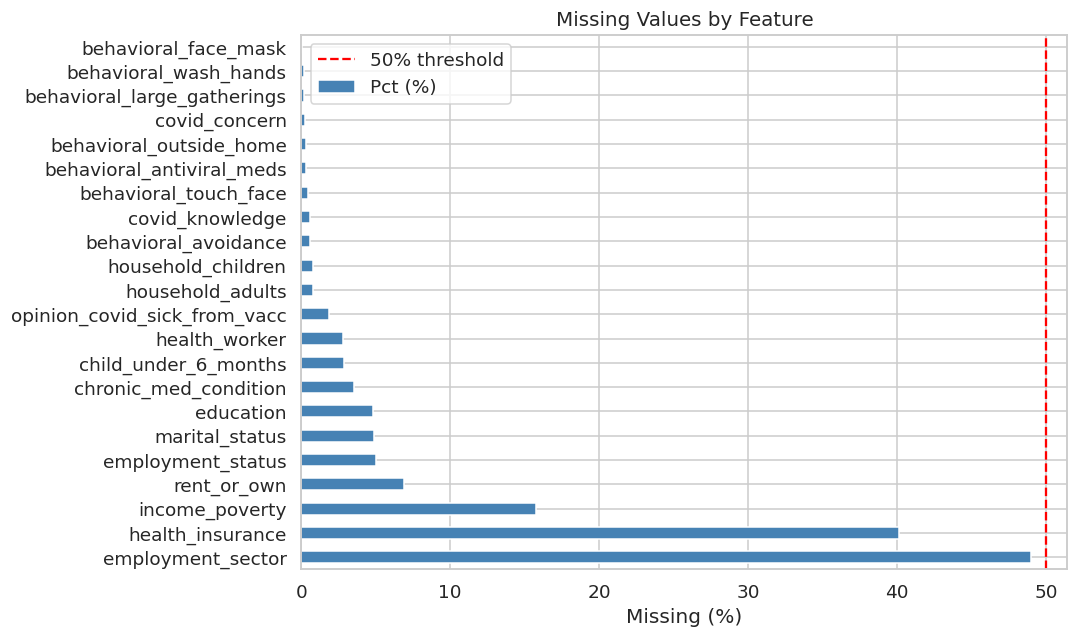

Key observations:
 employment_sector : 49.0% missing — nearly half the dataset
 health_insurance : 40.1% missing
 income_poverty : 15.7% missing


In [12]:
# To get the missing values by feature.
missing = train_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train_raw) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]
display(missing_df)

# To create the plot of missing values.
fig, ax = plt.subplots(figsize=(10, 6))
missing_df['Pct (%)'].plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(50, color='red', linestyle='--', label='50% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Feature')
ax.legend()
plt.tight_layout()
plt.show()

# To get the key observations from this.
print('Key observations:')
print(f' employment_sector : {train_raw["employment_sector"].isnull().mean()*100:.1f}% missing — nearly half the dataset')
print(f' health_insurance : {train_raw["health_insurance"].isnull().mean()*100:.1f}% missing')
print(f' income_poverty : {train_raw["income_poverty"].isnull().mean()*100:.1f}% missing')

## 4.2 Target variable distribution.

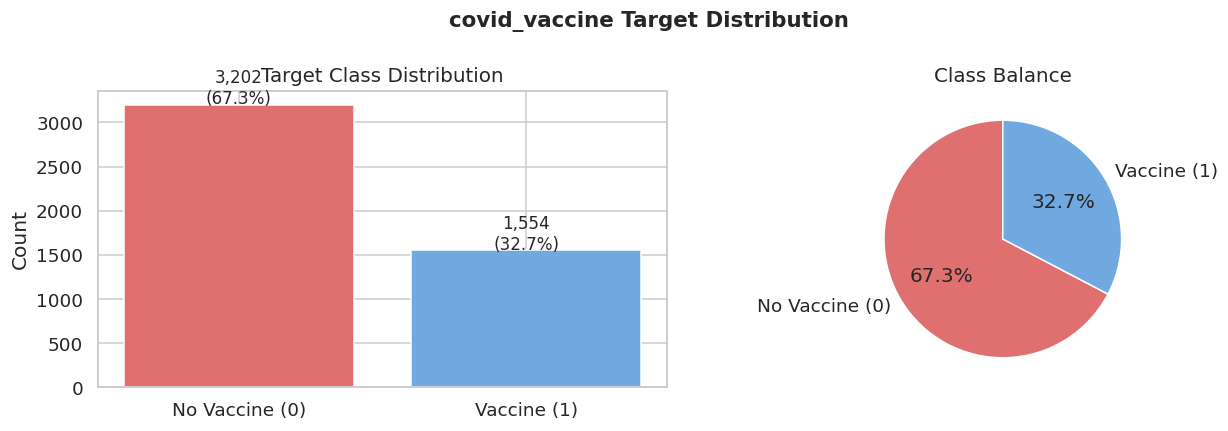

Class balance ratio: 0.485  (1.0 = perfectly balanced)
Imbalance note: ~67% did NOT get the vaccine — use class_weight="balanced"


In [13]:
# To visualize the target variable with 0 as a no vaccine and 1 as a vaccine.
vc = train_raw[TARGET_COL].value_counts()
labels = ['No Vaccine (0)', 'Vaccine (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# To create the bar plot of vaccine and non-vaccine.
bars = axes[0].bar(labels, vc.values, color=['#e07070', '#70a8e0'])
for bar, v in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 10,
                 f'{v:,}\n({v/len(train_raw)*100:.1f}%)',
                 ha='center', fontsize=11)
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')

# To create the pie chart of vaccine and non-vaccine.
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%',
            colors=['#e07070','#70a8e0'], startangle=90)
axes[1].set_title('Class Balance')

plt.suptitle('covid_vaccine Target Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# To see the class balance for vaccine and no vaccine.
balance = vc.min() / vc.max()
print(f'Class balance ratio: {balance:.3f}  (1.0 = perfectly balanced)')
print(f'Imbalance note: ~{vc[0]/len(train_raw)*100:.0f}% did NOT get the vaccine — use class_weight="balanced"')

## 4.3 Numeric Feature Distributions

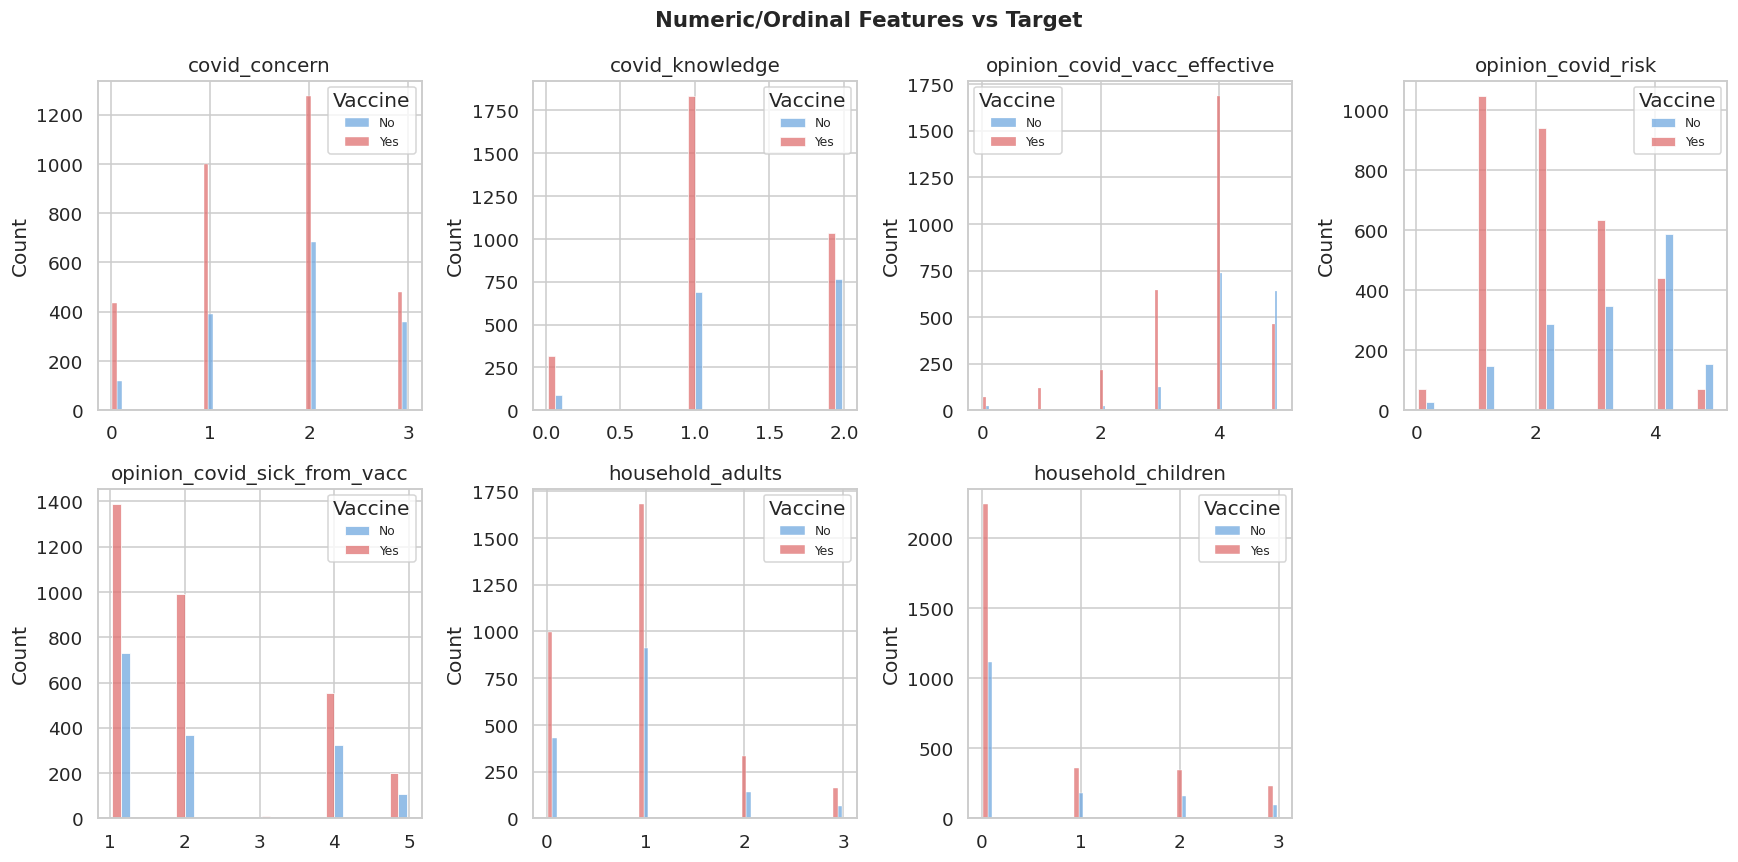

In [14]:
# To see the distribution of numeric features with vaccine and no vaccine.
num_cols = [ 'covid_concern', 'covid_knowledge',
             'opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc',
             'household_adults', 'household_children']

# To create the histogram of numeric with vaccine and no vaccine rate.
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=train_raw, x=col, hue=TARGET_COL,
                 multiple='dodge', ax=axes[i], palette={0:'#e07070', 1:'#70a8e0'},
                 shrink=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(title='Vaccine', labels=['No','Yes'], fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Numeric/Ordinal Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.4 Binary Feature Vaccination Rates

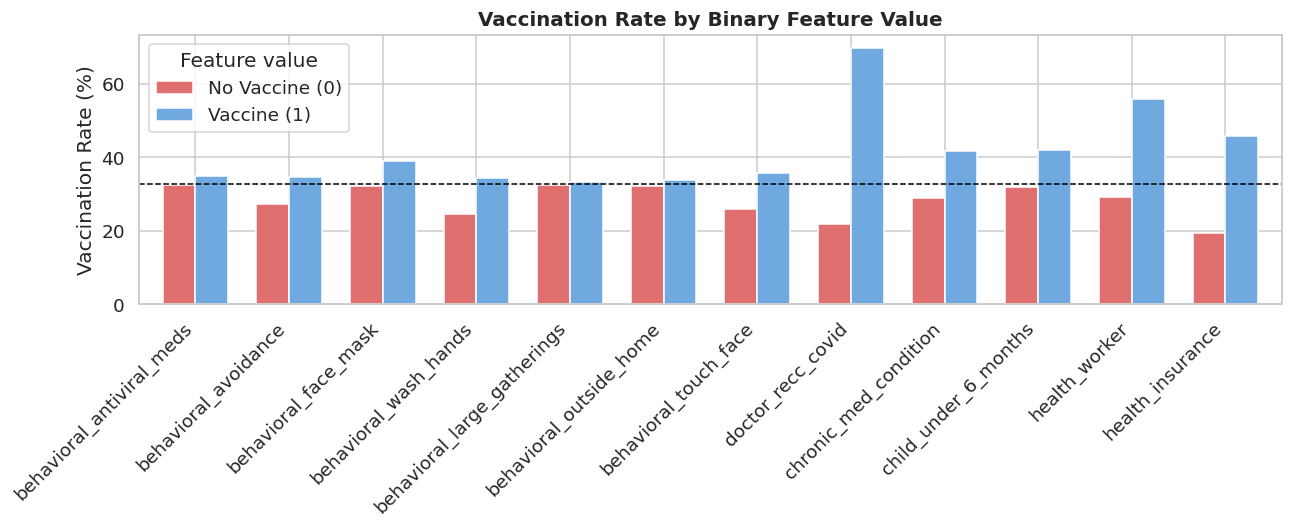

Biggest impact features (difference in vaccination rate):
doctor_recc_covid              48.150414
health_worker                  26.754892
health_insurance               26.386130
chronic_med_condition          12.777911
child_under_6_months           10.014453
behavioral_touch_face           9.916424
behavioral_wash_hands           9.622468
behavioral_avoidance            7.242837
behavioral_face_mask            6.728816
behavioral_antiviral_meds       2.258661
behavioral_outside_home         1.664773
behavioral_large_gatherings     0.861614


In [15]:
# To visualize the distribution of vaccine and no vaccine rate based on binary features.
binary_cols = [ 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask',
                'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home',
                'behavioral_touch_face', 'doctor_recc_covid', 'chronic_med_condition',
                'child_under_6_months', 'health_worker', 'health_insurance']

# Vaccination rate when feature = 1 vs 0
rates = {}
for col in binary_cols:
    # Calculate the mean of the TARGET_COL (covid_vaccine) where the binary feature is 0.
    # This gives the vaccination rate when the feature is absent/false.
    r0 = train_raw[train_raw[col] == 0][TARGET_COL].mean()
    # Calculate the mean of the TARGET_COL (covid_vaccine) where the binary feature is 1.
    # This gives the vaccination rate when the feature is present/true.
    r1 = train_raw[train_raw[col] == 1][TARGET_COL].mean()
    rates[col] = {'Feature=0': r0, 'Feature=1': r1}

rates_df = pd.DataFrame(rates).T * 100

fig, ax = plt.subplots(figsize=(12, 5))
rates_df.plot(kind='bar', ax=ax, color=['#e07070', '#70a8e0'], width=0.7)
ax.set_ylabel('Vaccination Rate (%)')
ax.set_title('Vaccination Rate by Binary Feature Value', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Feature value', labels=['No Vaccine (0)', 'Vaccine (1)'])
# Add a horizontal line for the overall average vaccination rate.
ax.axhline(train_raw[TARGET_COL].mean()*100, color='black',
           linestyle='--', linewidth=1, label='Overall average')
plt.tight_layout()
plt.show()

print('Biggest impact features (difference in vaccination rate):')
# Calculate the absolute difference in vaccination rates between Feature=1 and Feature=0.
rates_df['diff'] = (rates_df['Feature=1'] - rates_df['Feature=0']).abs()
# Print features sorted by the absolute difference in vaccination rates.
print(rates_df['diff'].sort_values(ascending=False).to_string())

## 4.5 Categorical Feature Vaccination Rates

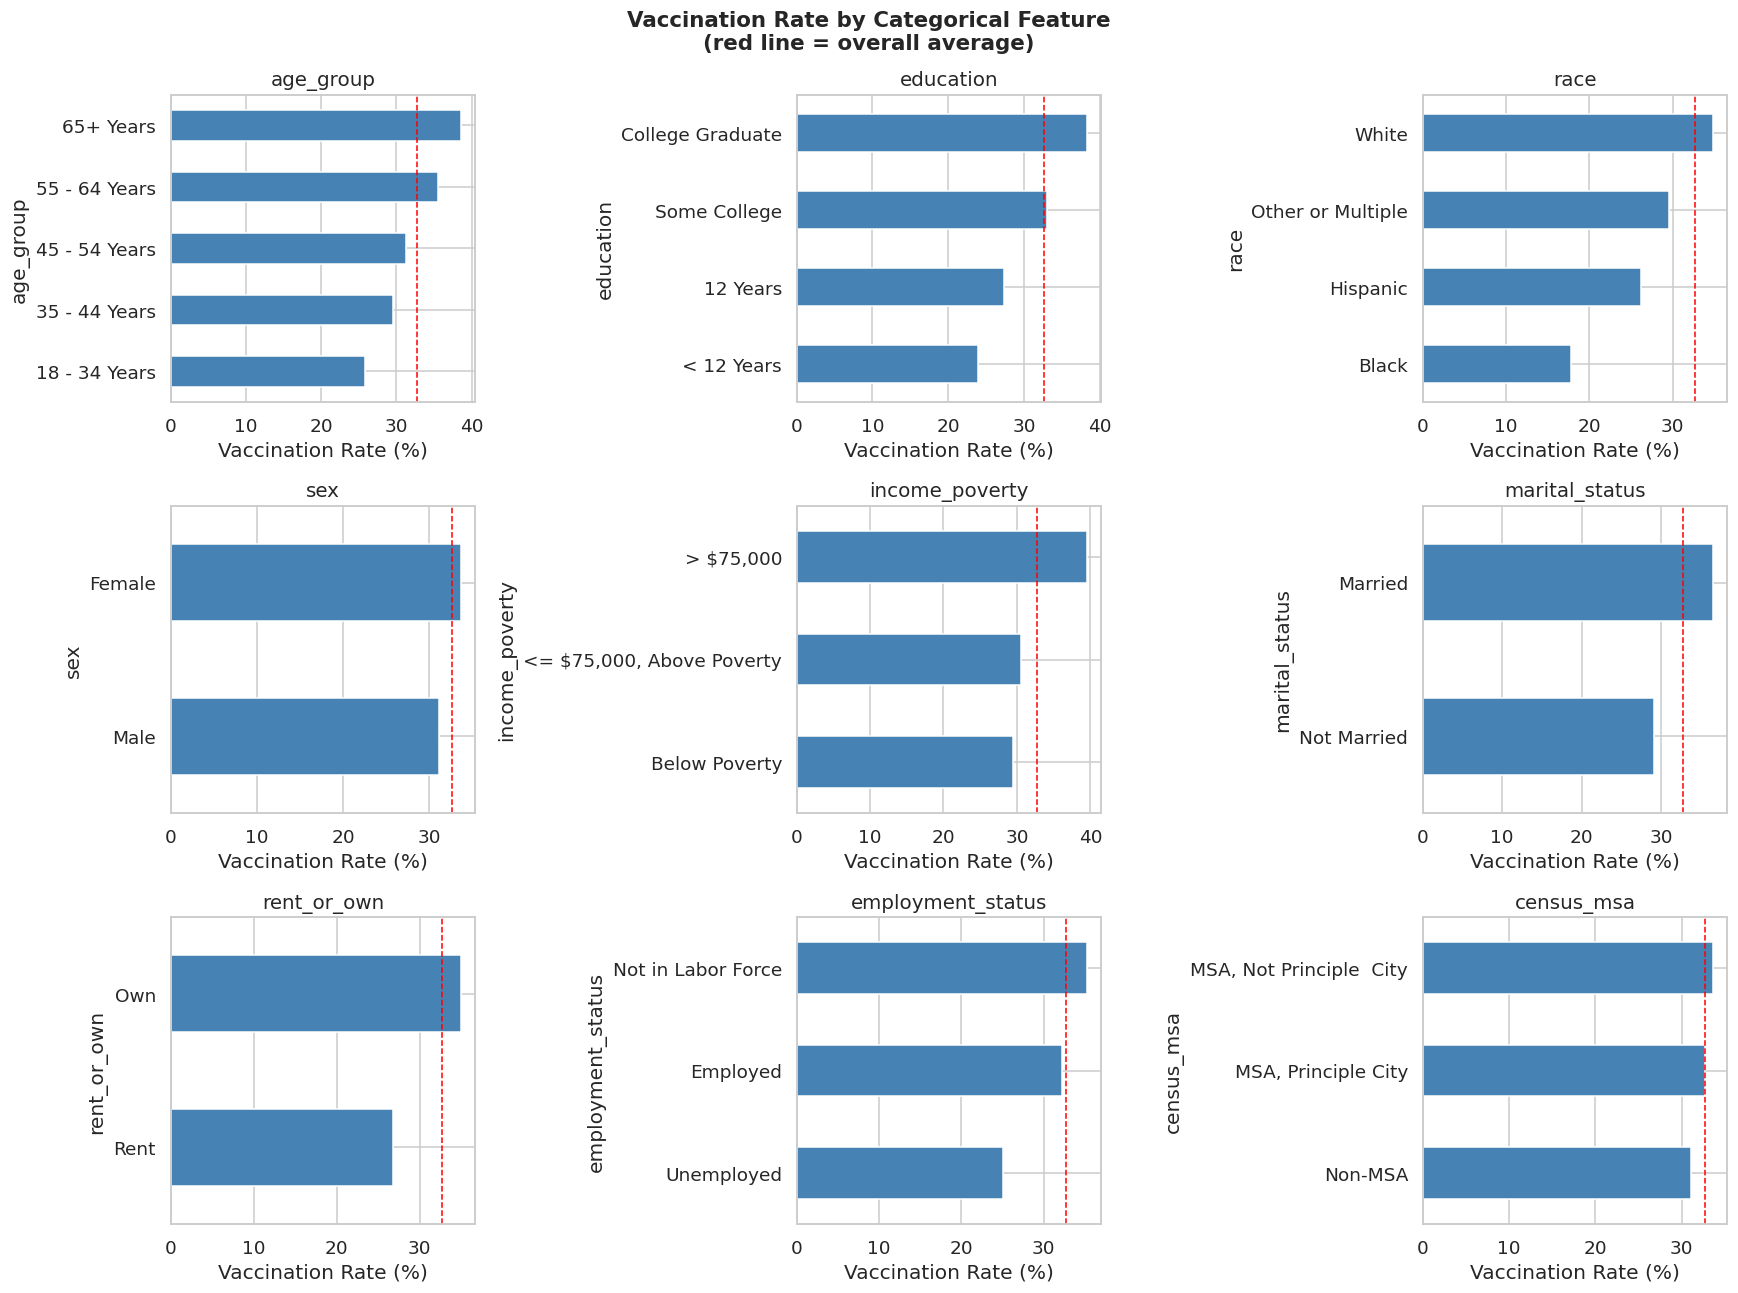

In [16]:
# Define a list of categorical columns to analyze.
cat_cols = [ 'age_group', 'education', 'race', 'sex',
             'income_poverty', 'marital_status', 'rent_or_own',
             'employment_status', 'census_msa']

# Create a figure and a grid of subplots (3 rows, 3 columns) for the visualizations.
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

# Loop through each categorical column to generate a horizontal bar plot.
for i, col in enumerate(cat_cols):
    # Calculate the mean vaccination rate (TARGET_COL) for each category within the current column.
    # The result is sorted and multiplied by 100 to represent it as a percentage.
    rate = train_raw.groupby(col)[TARGET_COL].mean().sort_values() * 100
    # Plot the calculated vaccination rates as horizontal bars on the current subplot.
    rate.plot(kind='barh', ax=axes[i], color='steelblue')
    # Add a vertical dashed red line representing the overall average vaccination rate for comparison.
    axes[i].axvline(train_raw[TARGET_COL].mean()*100, color='red',
                    linestyle='--', linewidth=1)
    axes[i].set_title(col)
    axes[i].set_xlabel('Vaccination Rate (%)')

plt.suptitle('Vaccination Rate by Categorical Feature\n(red line = overall average)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.6 Correlation Heatmap (Numeric Features)

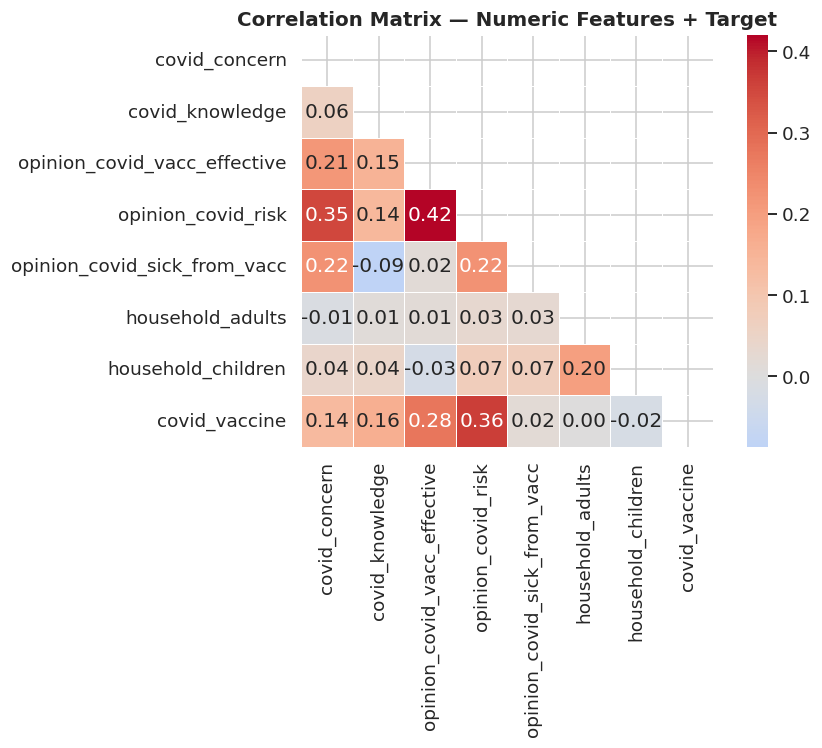

Correlation with target (sorted by absolute value):


,|corr with target|
opinion_covid_risk,0.364942
opinion_covid_vacc_effective,0.277309
covid_knowledge,0.164260
covid_concern,0.135191
household_children,0.021661
opinion_covid_sick_from_vacc,0.019444
household_adults,0.002741


In [17]:
# Combine numeric features and the target column for correlation analysis.
corr_cols = num_cols + [TARGET_COL]
# Calculate the pairwise correlation between the selected columns.
corr = train_raw[corr_cols].corr()

# Create a figure and an axes object for the heatmap.
fig, ax = plt.subplots(figsize=(9, 7))
# Create a mask to hide the upper triangle of the heatmap, as correlations are symmetric.
mask = np.triu(np.ones_like(corr, dtype=bool))
# Generate a heatmap using seaborn.
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Correlation Matrix — Numeric Features + Target', fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation with target (sorted by absolute value):')
# Display the absolute correlation values of each feature with the target variable,
# sorted in descending order, excluding the target itself.
display(corr[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False).to_frame('|corr with target|'))

## 4.7 Doctor Recommendation — Key Predictor Deep Dive

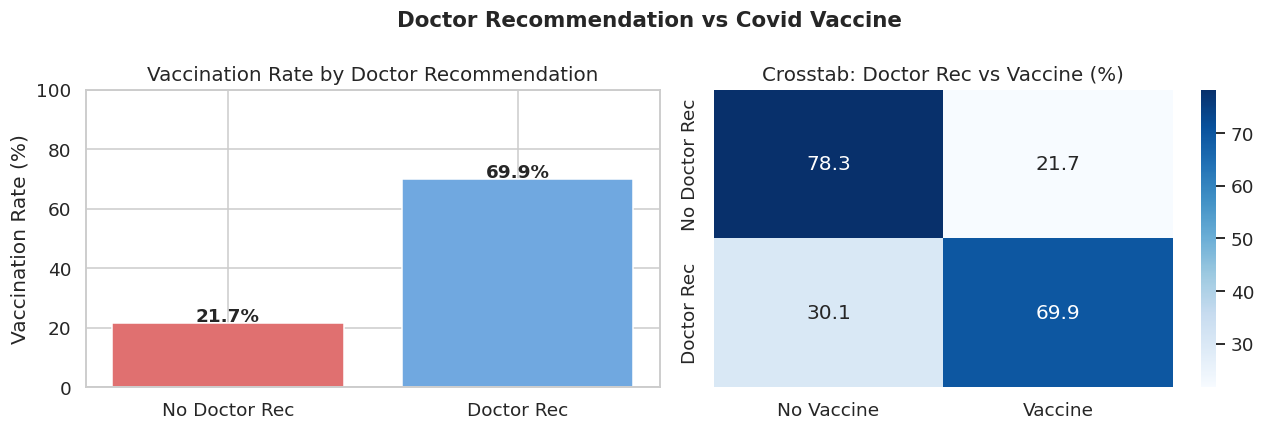

In [18]:
# Doctor recommendation is expected to be the strongest predictor.
# Create a figure with two subplots side-by-side.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

## Left Subplot: Vaccination rate by doctor recommendation.
# Group data by 'doctor_recc_covid' and calculate the mean vaccination rate.
doc_rates = train_raw.groupby('doctor_recc_covid')[TARGET_COL].mean() * 100
doc_rates.index = ['No Doctor Rec', 'Doctor Rec']

# Create a bar chart for vaccination rates.
bars = axes[0].bar(doc_rates.index, doc_rates.values, color=['#e07070','#70a8e0'])
for bar, v in zip(bars, doc_rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                 f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')

axes[0].set_title('Vaccination Rate by Doctor Recommendation')
axes[0].set_ylabel('Vaccination Rate (%)')
axes[0].set_ylim(0, 100)

## Right Subplot: Crosstab heatmap of doctor recommendation vs vaccine status.
# Create a cross-tabulation of 'doctor_recc_covid' and TARGET_COL, normalized by row (index),
# to show percentages of vaccine status for each doctor recommendation category.
ct = pd.crosstab(train_raw['doctor_recc_covid'],
                 train_raw[TARGET_COL], normalize='index') * 100
ct.index = ['No Doctor Rec', 'Doctor Rec']
ct.columns = ['No Vaccine', 'Vaccine']

# Create a heatmap of the cross-tabulation.
sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set_title('Crosstab: Doctor Rec vs Vaccine (%)')
plt.suptitle('Doctor Recommendation vs Covid Vaccine', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.8 Opinion Features Deep Dive

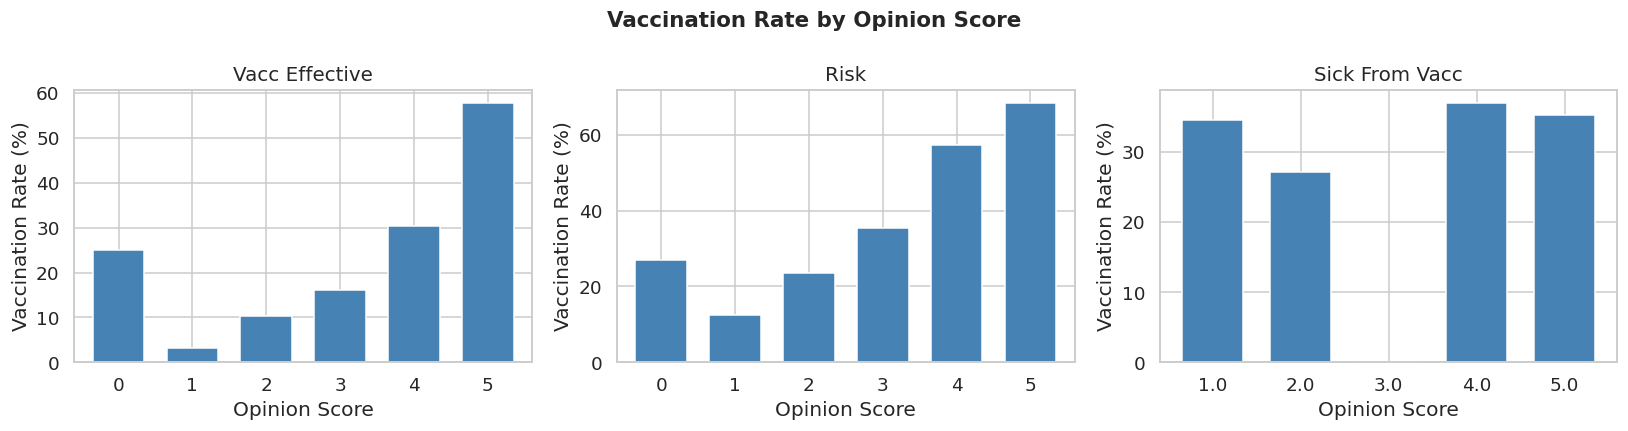

In [19]:
# Define a list of columns related to opinions on COVID-19.
opinion_cols = ['opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Loop through each opinion column to generate a bar plot.
for i, col in enumerate(opinion_cols):
    # Group the data by the current opinion column and calculate the mean vaccination rate for each opinion score.
    rate = train_raw.groupby(col)[TARGET_COL].mean() * 100
    rate.plot(kind='bar', ax=axes[i], color='steelblue', width=0.7)
    axes[i].set_title(col.replace('opinion_covid_', '').replace('_', ' ').title())
    axes[i].set_ylabel('Vaccination Rate (%)')
    axes[i].set_xlabel('Opinion Score')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)

plt.suptitle('Vaccination Rate by Opinion Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4.9 Missing Value Pattern Analysis

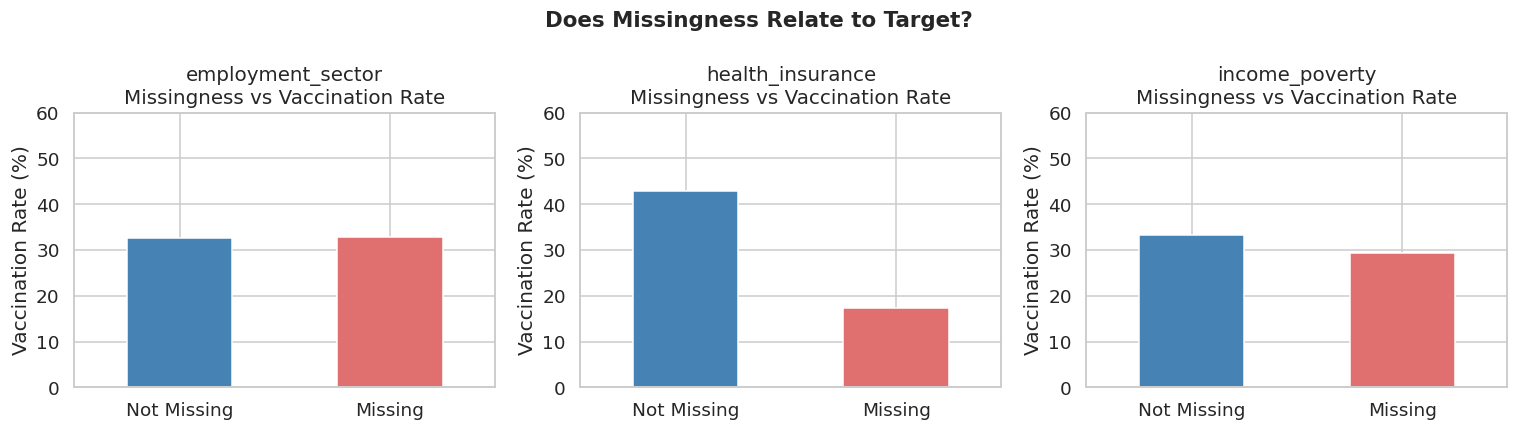

In [20]:
# To check if missingness in key columns is related to target.
# Define columns identified as having high rates of missing values.
high_miss_cols = ['employment_sector', 'health_insurance', 'income_poverty']

# Create a figure with three subplots arranged in one row.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(high_miss_cols):
    # Create a binary flag: 1 if the value is missing (null), 0 otherwise.
    miss_flag = train_raw[col].isnull().astype(int)
    rate = train_raw.groupby(miss_flag)[TARGET_COL].mean() * 100
    rate.index = ['Not Missing', 'Missing']
    rate.plot(kind='bar', ax=axes[i], color=['steelblue','#e07070'], width=0.5)
    axes[i].set_title(f'{col}\nMissingness vs Vaccination Rate')
    axes[i].set_ylabel('Vaccination Rate (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].set_ylim(0, 60)

plt.suptitle('Does Missingness Relate to Target?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Pre-processing

### 5.1 Feature Engineering — Missing Indicators


In [21]:
def add_missing_indicators(df, cols):
    """Add binary flag columns for high-missing features."""
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isnull().astype(int)
    return df

# Add missing indicators for columns with high missingness.
HIGH_MISS_COLS = ['employment_sector', 'health_insurance', 'income_poverty', 'marital_status']

train_fe = add_missing_indicators(train_raw, HIGH_MISS_COLS)
test_fe  = add_missing_indicators(test_raw,  HIGH_MISS_COLS)

print('New indicator columns added:')
new_cols = [f'{c}_missing' for c in HIGH_MISS_COLS]
print(new_cols)
display(train_fe[new_cols].sum().to_frame('# Missing flagged'))

New indicator columns added:
['employment_sector_missing', 'health_insurance_missing', 'income_poverty_missing', 'marital_status_missing']


,# Missing flagged
employment_sector_missing,2330
health_insurance_missing,1908
income_poverty_missing,748
marital_status_missing,231


## 5.2 Separate Features & Target — Train/Val Split

In [22]:
# Separate features (X) and target (y) for the training data.
# Drop the TARGET_COL and ID_COL from the training features.
X_all = train_fe.drop(columns=[TARGET_COL, ID_COL])
y_all = train_fe[TARGET_COL].copy()

# Extract respondent IDs from the test set (for submission later).
test_ids   = test_fe[ID_COL].copy()
X_test_raw = test_fe.drop(columns=[ID_COL])

# Perform an 80/20 stratified split of the training data into training and validation sets.
# stratify=y_all ensures that the proportion of target classes is maintained in both splits.
X_train, X_val, y_train, y_val = train_test_split( X_all, y_all,
                                                   test_size=0.20,
                                                   random_state=RANDOM_STATE,
                                                   stratify=y_all)

# Print the shapes of the resulting datasets and the value counts for the target variables.
print(f'X_train : {X_train.shape}   y_train: {y_train.value_counts().to_dict()}')
print(f'X_val   : {X_val.shape}     y_val  : {y_val.value_counts().to_dict()}')
print(f'X_test  : {X_test_raw.shape}')

X_train : (3804, 33)   y_train: {0: 2561, 1: 1243}
X_val   : (952, 33)     y_val  : {0: 641, 1: 311}
X_test  : (4749, 33)


## 5.3 Define Feature Groups

In [23]:
# Numeric/ordinal: impute with median, scale.
# To define a list of numeric and ordinal features.
numeric_features = ['covid_concern', 'covid_knowledge',
                    'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask',
                    'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home',
                    'behavioral_touch_face', 'chronic_med_condition', 'child_under_6_months',
                    'health_worker', 'health_insurance',
                    'household_adults', 'household_children',
                    'doctor_recc_covid',
                    'opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc',
                    # missing indicators (these are also numeric/binary)
                    'employment_sector_missing', 'health_insurance_missing',
                    'income_poverty_missing', 'marital_status_missing']

# Filter the list to include only columns that are actually present in the training data (after feature engineering).
numeric_features = [c for c in numeric_features if c in X_train.columns]

# Categorical: impute with 'Unknown', one-hot encode.
# Define a list of categorical features.
categorical_features = ['age_group', 'education', 'race', 'sex',
                        'income_poverty', 'marital_status', 'rent_or_own',
                        'employment_status', 'census_msa', 'employment_sector']

# Filter the list to include only columns that are actually present in the training data.
categorical_features = [c for c in categorical_features if c in X_train.columns]

# Print the final lists of numeric and categorical features.
print(f'Numeric features   ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numeric features   (23): ['covid_concern', 'covid_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'household_adults', 'household_children', 'doctor_recc_covid', 'opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc', 'employment_sector_missing', 'health_insurance_missing', 'income_poverty_missing', 'marital_status_missing']
Categorical features (10): ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


## 5.4 Build Two Preprocessing Pipelines A and B


In [24]:
## VERSION A — Median imputation + StandardScaler (default)

# Pipeline for numerical features in Version A:
# 1. Impute missing values with the median.
# 2. Scale features using StandardScaler (z-score standardization).
num_pipe_A = Pipeline([ ('imputer', SimpleImputer(strategy='median')),
                        ('scaler',  StandardScaler()),])
# Pipeline for categorical features in Version A:
# 1. Impute missing values with a constant string 'Unknown'.
# 2. Encode categorical features using OneHotEncoder.
cat_pipe_A = Pipeline([ ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
                        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),])
# Combine numerical and categorical pipelines using ColumnTransformer.
preprocessor_A = ColumnTransformer([('num', num_pipe_A, numeric_features),
                                    ('cat', cat_pipe_A, categorical_features),],
                                    remainder='drop') # Drop any columns not specified.

## VERSION B — Most frequent imputation + RobustScaler (better for outliers)

# Pipeline for numerical features in Version B:
# 1. Impute missing values with the most frequent value.
# 2. Scale features using RobustScaler (less sensitive to outliers).
num_pipe_B = Pipeline([ ('imputer', SimpleImputer(strategy='most_frequent')),
                        ('scaler',  RobustScaler()),])
# Pipeline for categorical features in Version B (same as A for this example):
# 1. Impute missing values with a constant string 'Unknown'.
# 2. Encode categorical features using OneHotEncoder.
cat_pipe_B = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),])
# Combine numerical and categorical pipelines using ColumnTransformer.
preprocessor_B = ColumnTransformer([('num', num_pipe_B, numeric_features),
                                    ('cat', cat_pipe_B, categorical_features),], remainder='drop') # Drop any columns not specified.

# Fit both preprocessors on the training data ONLY to avoid data leakage.
preprocessor_A.fit(X_train)
preprocessor_B.fit(X_train)

# Transform the training, validation, and test data using preprocessor A.
X_train_A = preprocessor_A.transform(X_train)
X_val_A   = preprocessor_A.transform(X_val)
X_test_A  = preprocessor_A.transform(X_test_raw)

# Transform the training, validation, and test data using preprocessor B.
X_train_B = preprocessor_B.transform(X_train)
X_val_B   = preprocessor_B.transform(X_val)
X_test_B  = preprocessor_B.transform(X_test_raw)

# Print the shapes of the processed data to confirm dimensions.
print(f'Version A processed shape: {X_train_A.shape}')
print(f'Version B processed shape: {X_train_B.shape}')

Version A processed shape: (3804, 78)
Version B processed shape: (3804, 78)


## 5.5 Select Active Preprocessing Version

In [25]:
# Set the active preprocessing version.
PREP_VERSION = 'A'

# Assign the processed datasets based on the selected PREP_VERSION.
if PREP_VERSION == 'A':
    X_train_proc = X_train_A
    X_val_proc   = X_val_A
    X_test_proc  = X_test_A
    active_prep  = preprocessor_A
else:
    X_train_proc = X_train_B
    X_val_proc    = X_val_B
    X_test_proc  = X_test_B
    active_prep  = preprocessor_B

# Build a list of feature names after one-hot encoding for later use (e.g., in XAI).
# This involves getting names from the OneHotEncoder within the ColumnTransformer.
try:
    ohe_names = active_prep.named_transformers_['cat']['encoder'] \
                .get_feature_names_out(categorical_features).tolist()
except Exception:
    # Handle cases where there might be no categorical features or an error in getting names.
    ohe_names = []

# Combine numeric feature names with the one-hot encoded categorical feature names.
feature_names = numeric_features + ohe_names

# Print the active preprocessing version and the total number of features.
print(f'Active preprocessing: Version {PREP_VERSION}')
print(f'Total features after encoding: {len(feature_names)}')

Active preprocessing: Version A
Total features after encoding: 78


# 6. Modelling & Cross-Validation Benchmark

## 6.1. Logistic Regression Model


In [26]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_model(model_instance, X_train, y_train, X_val, y_val):
    """
    Trains the given model_instance on X_train, y_train and evaluates it on X_val, y_val.
    Returns the fitted model, accuracy, F1-score, and ROC-AUC score.
    """
    model_instance.fit(X_train, y_train)
    y_pred = model_instance.predict(X_val)
    y_proba = model_instance.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    auc = roc_auc_score(y_val, y_proba)

    return model_instance, acc, f1, auc

model = LogisticRegression( max_iter=1000, class_weight='balanced',
                            random_state=RANDOM_STATE)

model.fit(X_train_proc, y_train)
preds = model.predict(X_test_proc)

model = LogisticRegression( max_iter=1000,class_weight='balanced',
                            random_state=RANDOM_STATE)

# To evaluate.
_, acc, f1, auc = evaluate_model(model, X_train_proc, y_train, X_val_proc, y_val)

# Fit on full training.
model.fit(X_train_proc, y_train)
preds = model.predict(X_test_proc)

print(f"Logistic Regression — AUC={auc:.4f}, F1={f1:.4f}")

Logistic Regression — AUC=0.8609, F1=0.7823


## 6.2 Decision Tree Model

In [27]:
# Initialize the Decision Tree Classifier with balanced class weights.
model = DecisionTreeClassifier( max_depth=6,
                                class_weight='balanced',
                                random_state=RANDOM_STATE)

# Evaluate the model on the validation set using the helper function.
_, acc, f1, auc = evaluate_model(model, X_train_proc, y_train, X_val_proc, y_val)

# Train the model on the full preprocessed training data.
model.fit(X_train_proc, y_train)
# Make predictions on the preprocessed test set.
preds = model.predict(X_test_proc)

print(f"Decision Tree — AUC={auc:.4f}, F1={f1:.4f}")

Decision Tree — AUC=0.7914, F1=0.7555


## 6.3. Random Forest Classifier Model

In [28]:
# Initialize the Random Forest Classifier with balanced class weights.
model = RandomForestClassifier( n_estimators=200,
                                class_weight='balanced',
                                random_state=RANDOM_STATE,
                                n_jobs=-1)

# Evaluate the model on the validation set using our helper function.
_, acc, f1, auc = evaluate_model(model, X_train_proc, y_train, X_val_proc, y_val)

# Train the model on the complete preprocessed training data.
model.fit(X_train_proc, y_train)
# Make predictions on the preprocessed test set.
preds = model.predict(X_test_proc)

print(f"Random Forest — AUC={auc:.4f}, F1={f1:.4f}")

Random Forest — AUC=0.8458, F1=0.7953


## 6.4. Gradient Boosting Model

In [29]:
# Initialize the Gradient Boosting Classifier.
model = GradientBoostingClassifier( n_estimators=200,
                                    random_state=RANDOM_STATE)

# Evaluate the model on the validation set.
_, acc, f1, auc = evaluate_model(model, X_train_proc, y_train, X_val_proc, y_val)

# Train the model on the full preprocessed training data.
model.fit(X_train_proc, y_train)
# Make predictions on the preprocessed test set.
preds = model.predict(X_test_proc)

print(f"Gradient Boosting — AUC={auc:.4f}, F1={f1:.4f}")

Gradient Boosting — AUC=0.8621, F1=0.8150


## 6.5. KNN (K-Nearest Neighbors Classifier)

In [30]:
# Initialize the K-Nearest Neighbors Classifier.
model = KNeighborsClassifier( n_neighbors=9,
                              n_jobs=-1)

# Evaluate the model on the validation set.
_, acc, f1, auc = evaluate_model(model, X_train_proc, y_train, X_val_proc, y_val)

# Train the model on the full preprocessed training data.
model.fit(X_train_proc, y_train)
# Make predictions on the preprocessed test set.
preds = model.predict(X_test_proc)

print(f"KNN — AUC={auc:.4f}, F1={f1:.4f}")

KNN — AUC=0.7953, F1=0.7464


## 6.6. XGBoost Model

In [31]:
# Initialize the XGBoost Classifier, accounting for class imbalance.
model = XGBClassifier( n_estimators=200,
                       scale_pos_weight=3202/1554,
                       use_label_encoder=False, # Suppress warning.
                       eval_metric='logloss', # Specify evaluation metric.
                       random_state=RANDOM_STATE,
                       n_jobs=-1)

# Evaluate the model on the validation set.
_, acc, f1, auc = evaluate_model(model, X_train_proc, y_train, X_val_proc, y_val)

# Train the model on the full preprocessed training data.
model.fit(X_train_proc, y_train)
# Make predictions on the preprocessed test set.
preds = model.predict(X_test_proc)

print(f"XGBoost — AUC={auc:.4f}, F1={f1:.4f}")

XGBoost — AUC=0.8153, F1=0.7767


## 6.7. LightGBM Model.

In [32]:
# Initialize the LightGBM Classifier with balanced class weights.
model = LGBMClassifier( n_estimators=200,
                        class_weight='balanced',
                        random_state=RANDOM_STATE,
                        verbose=-1, # Suppress verbose output.
                        n_jobs=-1)

# Evaluate the model on the validation set.
_, acc, f1, auc = evaluate_model(model, X_train_proc, y_train, X_val_proc, y_val)

# Train the model on the full preprocessed training data.
model.fit(X_train_proc, y_train)
# Make predictions on the preprocessed test set.
preds = model.predict(X_test_proc)

print(f"LightGBM — AUC={auc:.4f}, F1={f1:.4f}")

LightGBM — AUC=0.8415, F1=0.7833


## 6.8. 5‑Fold Stratified Cross‑Validation (All Models)


In [33]:
models = {'Logistic Regression': LogisticRegression(max_iter=1000,
                                                    class_weight='balanced',
                                                    random_state=RANDOM_STATE),
          'Decision Tree': DecisionTreeClassifier(max_depth=6,
                                                  class_weight='balanced',
                                                  random_state=RANDOM_STATE),
          'Random Forest': RandomForestClassifier(n_estimators=200,
                                                  class_weight='balanced',
                                                  random_state=RANDOM_STATE,
                                                  n_jobs=-1),
          'Gradient Boosting': GradientBoostingClassifier(n_estimators=200,
                                                          random_state=RANDOM_STATE),
          'KNN': KNeighborsClassifier(n_neighbors=9, n_jobs=-1),
          'XGBoost': XGBClassifier(n_estimators=200,
                                   scale_pos_weight=3202 / 1554,
                                   use_label_encoder=False,
                                   eval_metric='logloss',
                                   random_state=RANDOM_STATE,
                                   n_jobs=-1,),
          'LightGBM': LGBMClassifier(n_estimators=200,
                                     class_weight='balanced',
                                     random_state=RANDOM_STATE,
                                     verbose=-1,
                                     n_jobs=-1),}

# Set up 5-fold stratified cross-validation for balanced splits.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Dictionary to store cross-validation results for each model.
cv_results = {}

print("\n==== 5-FOLD STRATIFIED CROSS-VALIDATION (ROC-AUC) =====\n")

# Loop through each defined model and perform cross-validation.
for name, model in models.items():
    # Calculate ROC-AUC scores across 5 folds.
    scores = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    # Print the mean and standard deviation of the scores.
    print(f"{name:25s}  AUC mean={scores.mean():.4f}  std={scores.std():.4f}")


==== 5-FOLD STRATIFIED CROSS-VALIDATION (ROC-AUC) =====

Logistic Regression        AUC mean=0.8541  std=0.0092
Decision Tree              AUC mean=0.8051  std=0.0098
Random Forest              AUC mean=0.8526  std=0.0128
Gradient Boosting          AUC mean=0.8588  std=0.0119
KNN                        AUC mean=0.7990  std=0.0025
XGBoost                    AUC mean=0.8273  std=0.0194
LightGBM                   AUC mean=0.8441  std=0.0142


## 6.9. Train & Evaluate on Validation Set (All Models)

In [34]:
# Dictionaries to hold all trained models and their validation metrics.
trained_models = {}
val_results = {}

print("\n===== VALIDATION SET PERFORMANCE =====\n")

# Iterate through each model to train and evaluate.
for name, model in models.items():
    # Train the model on the preprocessed training data.
    model.fit(X_train_proc, y_train)
    # Store the trained model.
    trained_models[name] = model

    # Make predictions and get probabilities on the validation set.
    preds = model.predict(X_val_proc)
    proba = model.predict_proba(X_val_proc)[:, 1]

    # Calculate key evaluation metrics.
    val_results[name] = { 'Accuracy'  : accuracy_score(y_val, preds),
                          'Precision' : precision_score(y_val, preds, zero_division=0),
                          'Recall'    : recall_score(y_val, preds, zero_division=0),
                          'F1'        : f1_score(y_val, preds),
                          'AUC'       : roc_auc_score(y_val, proba)}

# Convert results to a DataFrame for clear comparison.
results_df = pd.DataFrame(val_results).T
# Display the leaderboard, sorted by AUC, highlighting the best performer.
display(results_df.sort_values('AUC', ascending=False)
        .style.highlight_max(color='lightgreen').format('{:.4f}'))
# Sort by F1 score (best → worst)
top5_names = results_df.sort_values('F1', ascending=False).head(5).index.tolist()

print('Top 5 models by F1-score (best → worst):')
for rank, name in enumerate(top5_names, 1):
    print(f'  {rank}. {name:35s}  F1={results_df.loc[name, "F1"]:.4f}')



===== VALIDATION SET PERFORMANCE =====



,Accuracy,Precision,Recall,F1,AUC
Gradient Boosting,0.8193,0.7643,0.6463,0.7003,0.8621
Logistic Regression,0.7773,0.6286,0.7781,0.6954,0.8609
Random Forest,0.8036,0.7650,0.5756,0.6569,0.8458
LightGBM,0.7826,0.6625,0.6817,0.6719,0.8415
XGBoost,0.7763,0.6551,0.6656,0.6603,0.8153
KNN,0.7595,0.6881,0.4823,0.5671,0.7953
Decision Tree,0.7500,0.5953,0.7331,0.6571,0.7914


Top 5 models by F1-score (best → worst):
  1. Gradient Boosting                    F1=0.7003
  2. Logistic Regression                  F1=0.6954
  3. LightGBM                             F1=0.6719
  4. XGBoost                              F1=0.6603
  5. Decision Tree                        F1=0.6571


## 6.10. Confusion Matrices (All Models)

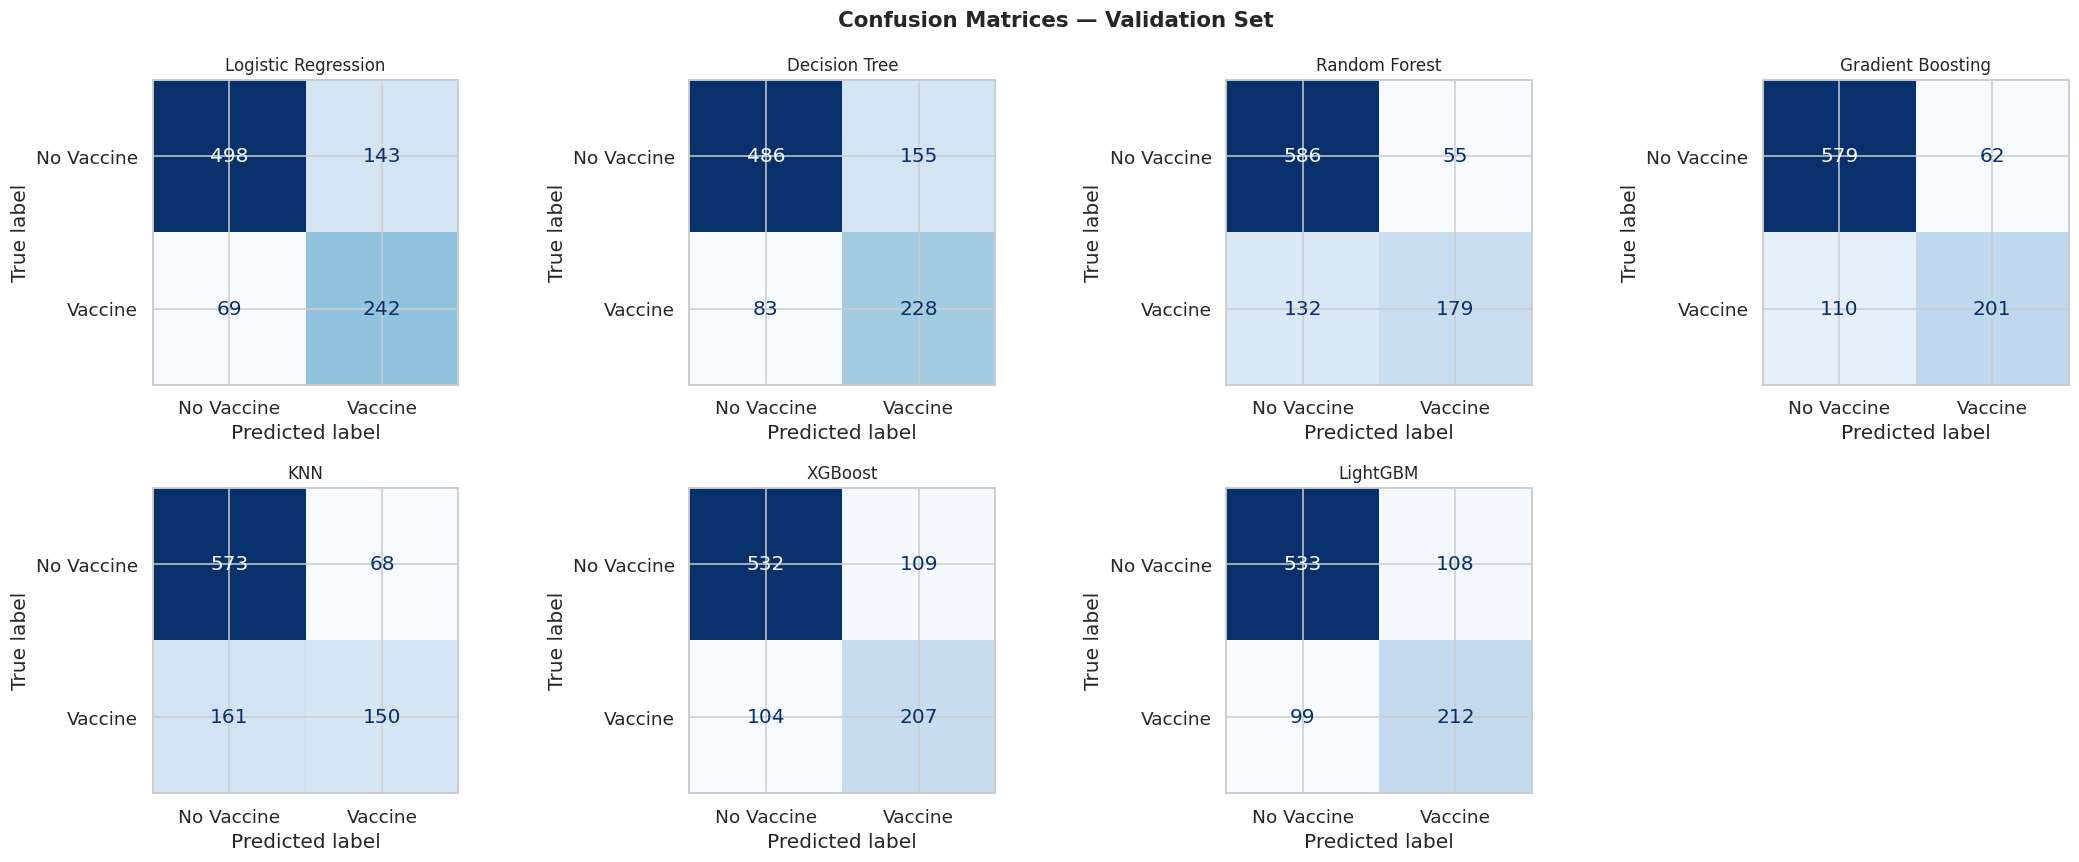

In [35]:
# Determine grid layout for confusion matrix plots.
n = len(trained_models)
cols = 4
rows = (n + cols - 1) // cols # Calculate rows needed

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten() # Flatten for easy iteration

# Plot confusion matrix for each trained model.
for i, (name, model) in enumerate(trained_models.items()):
    cm = confusion_matrix(y_val, model.predict(X_val_proc))
    ConfusionMatrixDisplay(cm, display_labels=['No Vaccine','Vaccine']).plot(
        ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=11)

# Hide any unused subplots.
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — Validation Set", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6.11. ROC Curves — All Models

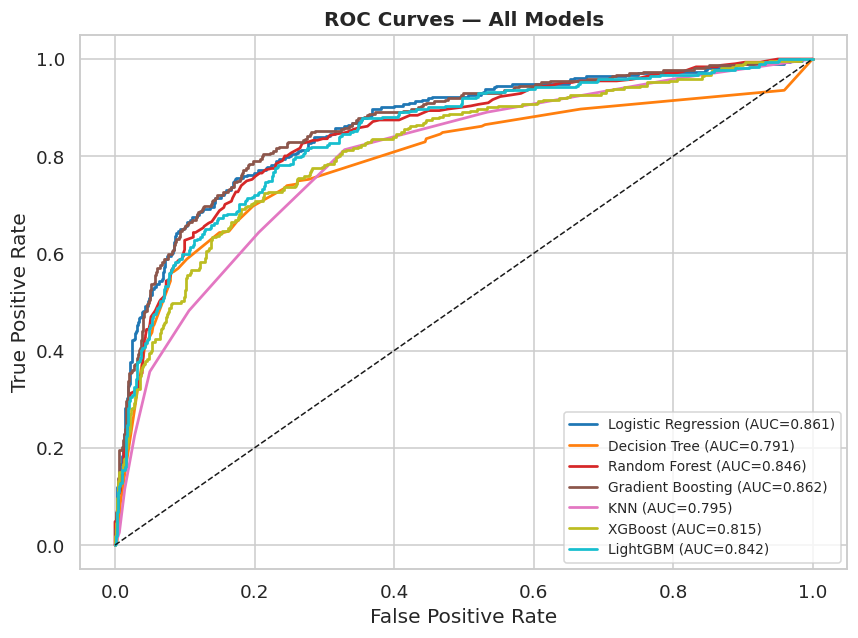

In [36]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))
# Get a color palette for plotting each model's ROC curve.
colors = plt.cm.tab10(np.linspace(0, 1, len(trained_models)))

# Plot ROC curve for each trained model.
for (name, model), color in zip(trained_models.items(), colors):
    proba = model.predict_proba(X_val_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = val_results[name]['AUC'] # Retrieve AUC from validation results.
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=1.8)

# Plot the random guess line (AUC=0.5).
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models", fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 6.12. Classification Report — top 5 Best Model

In [37]:
# To sort models by F1 score (highest first).
sorted_models = results_df.sort_values('F1', ascending=False)

# To get the top 5 models.
top5 = sorted_models.head(5).index.tolist()

print("Top 5 Models:", top5)

print("\n===== CLASSIFICATION REPORTS FOR TOP 5 MODELS =====\n")

for name in top5:
    model = trained_models[name]
    preds = model.predict(X_val_proc)
    print(f" MODEL: {name}")

    print(classification_report(y_val, preds,
                                target_names=['No Vaccine (0)', 'Vaccine (1)']))


Top 5 Models: ['Gradient Boosting', 'Logistic Regression', 'LightGBM', 'XGBoost', 'Decision Tree']

===== CLASSIFICATION REPORTS FOR TOP 5 MODELS =====

 MODEL: Gradient Boosting
                precision    recall  f1-score   support

No Vaccine (0)       0.84      0.90      0.87       641
   Vaccine (1)       0.76      0.65      0.70       311

      accuracy                           0.82       952
     macro avg       0.80      0.77      0.79       952
  weighted avg       0.82      0.82      0.82       952

 MODEL: Logistic Regression
                precision    recall  f1-score   support

No Vaccine (0)       0.88      0.78      0.82       641
   Vaccine (1)       0.63      0.78      0.70       311

      accuracy                           0.78       952
     macro avg       0.75      0.78      0.76       952
  weighted avg       0.80      0.78      0.78       952

 MODEL: LightGBM
                precision    recall  f1-score   support

No Vaccine (0)       0.84      0.83      

# 7. Submission Files

In [38]:
import os

os.makedirs(SUBMISSION_DIR, exist_ok=True)

# To Build results table.
results_final = pd.DataFrame(val_results).T

# To rank the models by F1 score (best → worst).
top5_names = results_final.sort_values('F1', ascending=False).head(5).index.tolist()

print('Top 5 models by F1-score (best → worst):')
for rank, name in enumerate(top5_names, 1):
    print(f'  {rank}. {name:35s}  F1={results_final.loc[name, "F1"]:.4f}')

print()
saved = []

# To genrate the submission files.
for rank, name in enumerate(top5_names, 1):
    model = trained_models[name]
    preds = model.predict(X_test_proc)
    sub = pd.DataFrame({ ID_COL: test_ids, TARGET_COL: preds})
    safe_name = name.replace(' ', '_').lower()

    # Filename includes rank + model name + f1 tag.
    fname = f'challenge_submission_group_{GROUP_NUMBER}_order_{rank}_{safe_name}_f1.csv'
    fpath = os.path.join(SUBMISSION_DIR, fname)

    sub.to_csv(fpath, index=False)
    saved.append((rank, name, fpath))

    print(f'  Saved (rank {rank}): {fname}  ← {name}')

print('\n All 5 submission files saved to your Google Drive folder:')
print(f'   {SUBMISSION_DIR}')

print('\n Final mapping (rank → model → file):')
for rank, name, path in saved:
    print(f'  {rank}. {name:35s}  →  {os.path.basename(path)}')


Top 5 models by F1-score (best → worst):
  1. Gradient Boosting                    F1=0.7003
  2. Logistic Regression                  F1=0.6954
  3. LightGBM                             F1=0.6719
  4. XGBoost                              F1=0.6603
  5. Decision Tree                        F1=0.6571

  Saved (rank 1): challenge_submission_group_X_order_1_gradient_boosting_f1.csv  ← Gradient Boosting
  Saved (rank 2): challenge_submission_group_X_order_2_logistic_regression_f1.csv  ← Logistic Regression
  Saved (rank 3): challenge_submission_group_X_order_3_lightgbm_f1.csv  ← LightGBM
  Saved (rank 4): challenge_submission_group_X_order_4_xgboost_f1.csv  ← XGBoost
  Saved (rank 5): challenge_submission_group_X_order_5_decision_tree_f1.csv  ← Decision Tree

 All 5 submission files saved to your Google Drive folder:
   /content/drive/MyDrive/hackathon/submissions/

 Final mapping (rank → model → file):
  1. Gradient Boosting                    →  challenge_submission_group_X_order_1_gradi

# 8. Explainable AI (SHAP)

## 8.1 SHAP Summary Plot (Beeswarm)

SHAP Summary Plot — Gradient Boosting


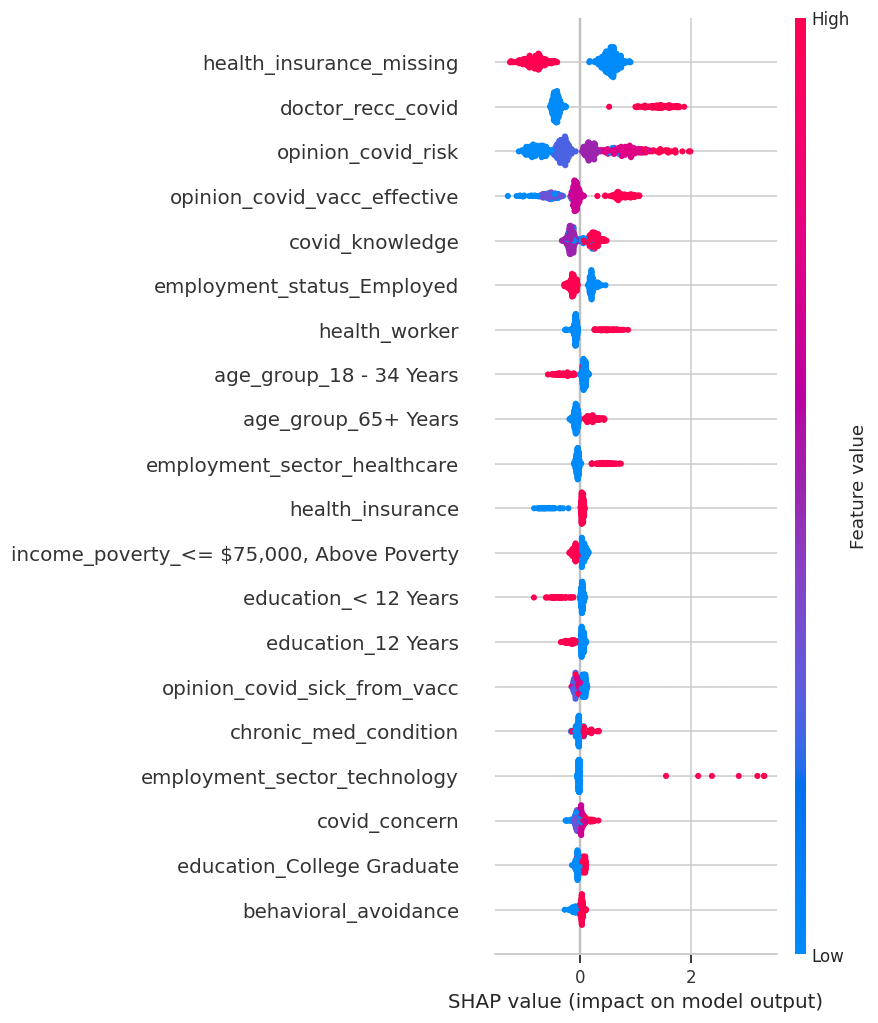

In [39]:
# Shows which features push the prediction higher or lower for each person.
# Pink = high feature value, Blue = low feature value.

tree_name   = 'Gradient Boosting'
model_shap  = trained_models[tree_name]

# We only use 500 people from the validation set to make it faster.
sample_size = min(500, X_val_proc.shape[0])
X_shap      = X_val_proc[:sample_size]

# Get the feature names so the plot shows proper labels.
feat_names_shap = feature_names[:X_shap.shape[1]]

try:
    # Create the SHAP explainer using our trained model.
    explainer   = shap.TreeExplainer(model_shap)

    # Calculate SHAP values — one value per person per feature.
    # This tells us how much each feature pushed the prediction up or down.
    shap_values = explainer.shap_values(X_shap)

    # For binary classification we need class 1 (vaccine = yes).
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    # Each dot is one person.
    # Pink dot = that person had a high value for that feature.
    # Blue dot = that person had a low value for that feature.
    # Dots on the right = that feature pushed the model to predict vaccine = yes.
    # Dots on the left  = that feature pushed the model to predict vaccine = no.
    print(f'SHAP Summary Plot — {tree_name}')
    shap.summary_plot(sv, X_shap, feature_names=feat_names_shap, show=True)

except Exception as e:
    print(f'Error: {e}')

## 8.2 SHAP Dependence Plot — Top Feature

Top feature: health_insurance_missing


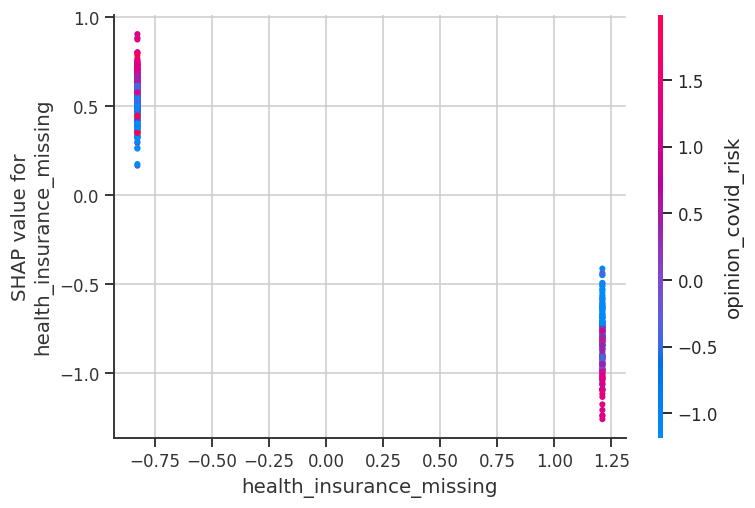

In [40]:
# Shows how the top feature affects the prediction.
# Each dot is one person. Colour shows a second interacting feature.

# To find which feature had the biggest impact overall.
top_idx = int(np.abs(sv).mean(axis=0).argmax())
print(f'Top feature: {feat_names_shap[top_idx]}')

# Plot how this feature affects the prediction for every person.
# The colour shows a second feature that interacts with this one.
shap.dependence_plot(top_idx, sv, X_shap,
                     feature_names=feat_names_shap, show=True)

## 8.3 SHAP Waterfall Plot — 3 Individual Predictions Explained

Waterfall plot — person 1


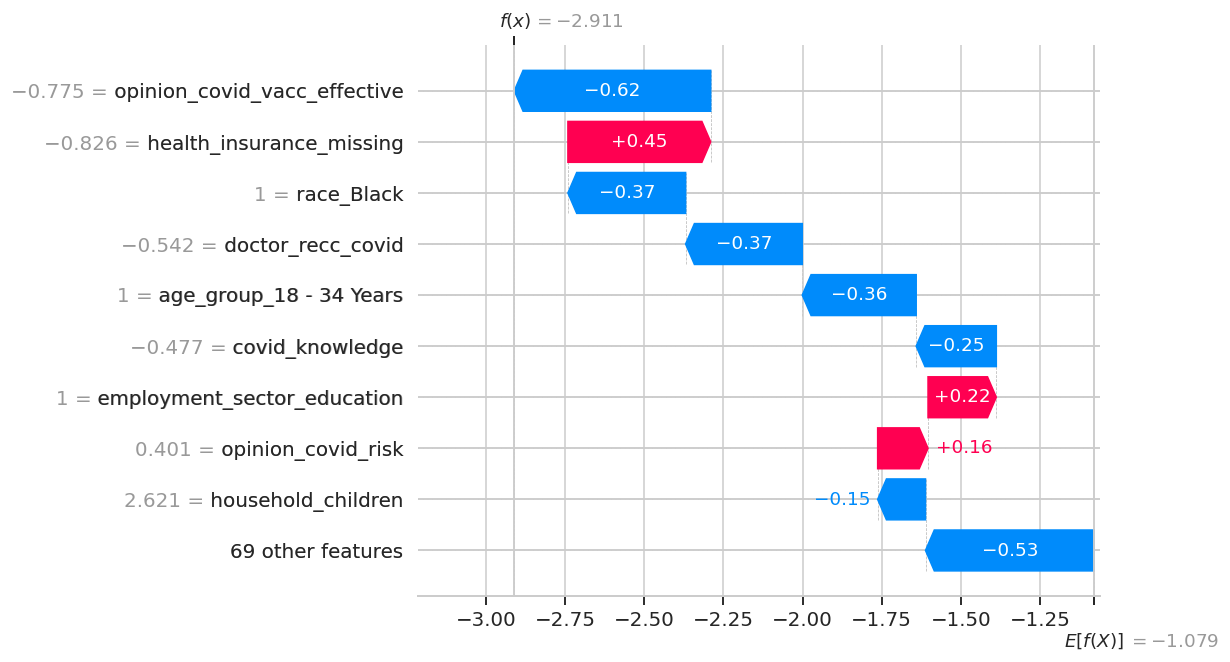

Waterfall plot — person 2


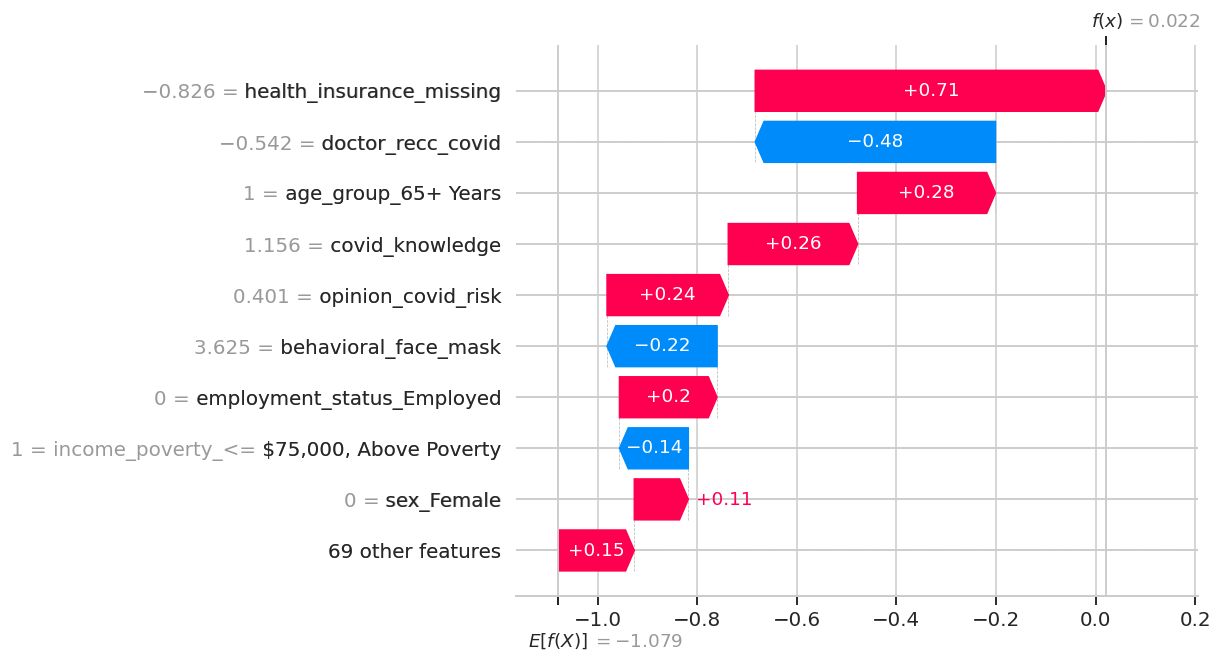

Waterfall plot — person 3


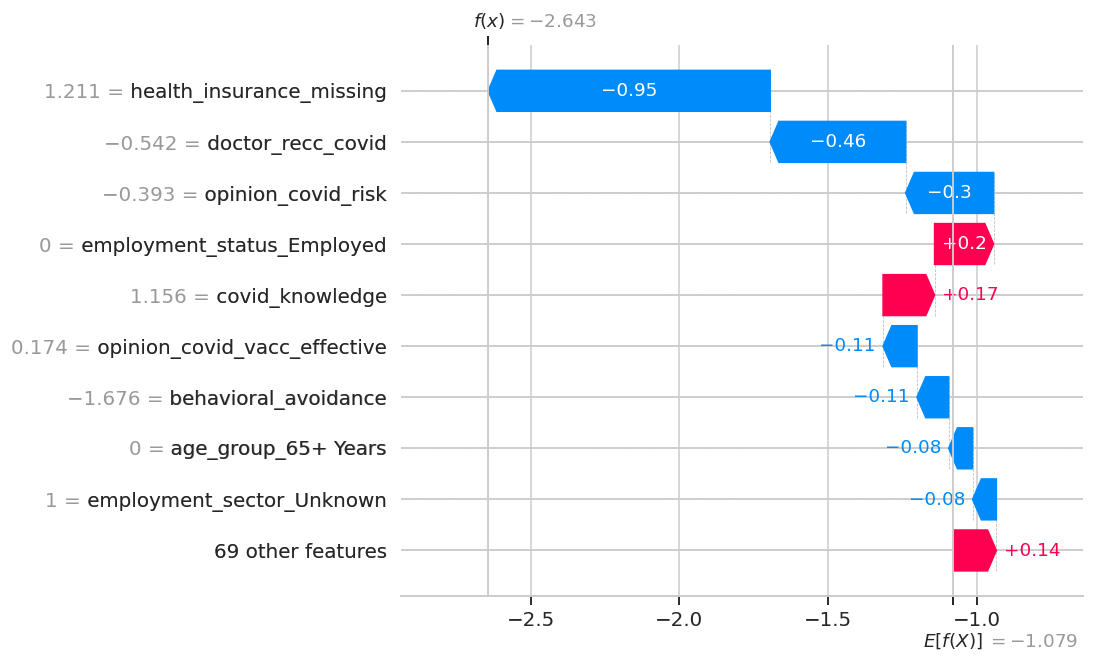

In [41]:
# A waterfall plot explains the prediction for just one person at a time.
# It shows which features pushed the prediction up (red) or down (blue).
# We do this for 3 different people so we can compare.

try:
    explanation = explainer(X_shap)

    # For binary classification we need class 1 (vaccine = yes).
    if len(explanation.shape) == 3:
        explanation = explanation[:, :, 1]

    # To loop through 3 people and show a waterfall plot for each one.
    for i in range(3):
        print(f'Waterfall plot — person {i+1}')
        shap.waterfall_plot(
        shap.Explanation( values=explanation[i].values,
                          base_values=explanation[i].base_values,
                          data=explanation[i].data,
                          feature_names=feat_names_shap),
        max_display=10, show=True)

except Exception as e:
    print(f'Waterfall plot error: {e}')